

Till now we know:

* Convolution → find patterns
* Filters → detect features
* Pooling → reduce size

Now the biggest question:

> **After all this… how does CNN actually give the final answer?**
> (like digit = 7, or cat vs dog)

That’s what we solve now.

---

# 🎬 Chapter 6 — Flatten and Dense Layer (Final Decision Making)

## 🎭 Characters

👩 **Riya**
👨‍🏫 **Professor Arjun**
🤖 **Milo**

---

# 🌅 Scene: The Final Decision

Riya looks at the output after pooling.

> **Riya:** Sir… now we have a smaller image… but how do we get the final answer?

Professor Arjun smiles.

> **Now comes the decision-making brain of CNN.**

Milo writes:

```text
Flatten → Convert image to list
Dense Layer → Make final decision
```

---

# 🧠 Step 1 — The Problem

After pooling, data looks like:

```text
(13 × 13 × 1)
```

This is still a **matrix (image-like)**.

But traditional ML models (like logistic regression) expect:

```text
1D data → a simple list
```

So we must convert:

```text
Image → List
```

---

# 🧠 Step 2 — What is Flatten?

Flatten means:

```text
Convert multi-dimensional data into 1D array
```

---

# 😄 Simple intuition

Professor Arjun says:

> **Imagine a chocolate box (matrix).
> Flatten means opening it and putting all chocolates in a straight line.**

---

# 📊 Example

Before flatten:

```text
[ 1  2 ]
[ 3  4 ]
```

After flatten:

```text
[ 1  2  3  4 ]
```

---

# 🧠 Step 3 — Why Flatten is needed?

Because Dense layers (normal neural network layers) only understand:

```text
1D input
```

---

# 🧠 Step 4 — What is Dense Layer?

Dense layer means:

```text
Every input connects to every neuron
```

---

# 😄 Simple intuition

Professor Arjun says:

> **Dense layer is like a group discussion.
> Every feature gives its opinion before making a decision.**

---

# 🧠 Step 5 — How decision is made?

After flatten:

* numbers represent features
* dense layer combines them
* final layer outputs probabilities

Example:

```text
Digit probabilities:
0 → 0.01  
1 → 0.02  
2 → 0.90  
3 → 0.05  

Final answer = 2
```

In [1]:
# 🧪 Step 1 — Import libraries

# Import tensorflow
import tensorflow as tf

# Import layers and models
from tensorflow.keras import layers, models

# Import matplotlib
import matplotlib.pyplot as plt

In [2]:

# 🧪 Step 2 — Load dataset

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()


# 🧪 Step 3 — Normalize and reshape

# Normalize pixel values (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape into CNN format
x_train = x_train.reshape((60000, 28, 28, 1))
x_test = x_test.reshape((10000, 28, 28, 1))


In [3]:


# 🧪 Step 4 — Build Full CNN Model

# Create model
model = models.Sequential()

# Step 1: Convolution layer
model.add(
    layers.Conv2D(
        32,                # 32 filters
        (3, 3),            # filter size
        activation="relu",
        input_shape=(28, 28, 1)
    )
)

# Step 2: Pooling layer
model.add(
    layers.MaxPooling2D((2, 2))  # reduce size
)

# Step 3: Flatten layer
model.add(
    layers.Flatten()  # convert 2D → 1D
)

# Step 4: Dense layer (hidden layer)
model.add(
    layers.Dense(64, activation="relu")  # 64 neurons
)

# Step 5: Output layer
model.add(
    layers.Dense(10, activation="softmax")  # 10 classes (digits 0–9)
)


C:\Users\Edunet Foundation\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)




---

# 🧠 Code Explanation (VERY IMPORTANT)

### Convolution

```python
layers.Conv2D(32, (3,3))
```

→ finds patterns using 32 filters

---

### Pooling

```python
MaxPooling2D((2,2))
```

→ reduces size

---

### Flatten

```python
Flatten()
```

→ converts image into list

---

### Dense (hidden layer)

```python
Dense(64)
```

→ learns combinations of features

---

### Output layer

```python
Dense(10, activation="softmax")
```

→ gives probability of each digit

---

In [ ]:
# 🧪 Step 5 — Compile model

# Compile model
model.compile(
    optimizer="adam",                 # learning method
    loss="sparse_categorical_crossentropy",  # loss function
    metrics=["accuracy"]              # track accuracy
)



# 🧠 Explanation

* **optimizer** → how model learns
* **loss** → how wrong prediction is
* **accuracy** → performance measure

In [5]:

# 🧪 Step 6 — Train model

# Train the model
model.fit(x_train, y_train, epochs=3)



Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9485 - loss: 0.1714
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9817 - loss: 0.0607
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9875 - loss: 0.0400


---

# 🧠 What happens here?

* images go in
* predictions happen
* errors calculated
* weights updated
* model improves

---

In [6]:



# 🧪 Step 7 — Evaluate model

# Test accuracy
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9836 - loss: 0.0492
Test Accuracy: 0.9836000204086304


In [7]:

# 🧪 Step 8 — Make prediction

# Predict one image
prediction = model.predict(x_test[0:1])

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
[[2.1614128e-06 9.2777793e-07 3.4447139e-06 2.5865693e-06 3.2442671e-09
  7.7281037e-08 2.1545647e-11 9.9998939e-01 7.6708767e-07 6.6275771e-07]]


---

# 🧠 Output meaning

[0.01, 0.00, 0.95, 0.02, ...]


Means:

Digit = 2 (highest probability)


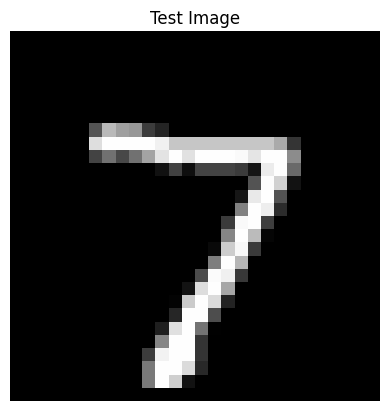

In [8]:
# 🧪 Step 9 — Show image

# Show the test image
plt.imshow(x_test[0, :, :, 0], cmap="gray")
plt.title("Test Image")
plt.axis("off")
plt.show()



# 🧪  Practice

### Practice 1

Change neurons:

```python
Dense(128)
```

Ask:

```text
Does accuracy improve?
```

---

### Practice 2

Remove flatten (try it)

Ask:

```text
Does model work or throw error?
```

---

### Practice 3

Change output classes:

```python
Dense(5)
```

Ask:

```text
What happens if labels don’t match?
```

---
